In [1]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cmocean.cm as cm
import numpy as np

In [2]:
file_iona = xr.open_dataset("/ocean/atall/MOAD/Obs/PugetSound/WWTP/wastewater_20231010_iona.nc")
print(file_iona.data_vars)
print(file_iona.coords)
print(file_iona.dims)

Data variables:
    nav_lat          (y, x) float32 1MB ...
    nav_lon          (y, x) float32 1MB ...
    area             (y, x) float64 3MB ...
    flux             (time_counter, y, x) float64 34MB ...
    temperature      (time_counter, y, x) float64 34MB ...
    NO3              (time_counter, y, x) float64 34MB ...
    NH3              (time_counter, y, x) float64 34MB ...
    dSi              (time_counter, y, x) float64 34MB ...
    diatoms          (time_counter, y, x) float64 34MB ...
    nanoflagellates  (time_counter, y, x) float64 34MB ...
    Z1               (time_counter, y, x) float64 34MB ...
    PON              (time_counter, y, x) float64 34MB ...
    DON              (time_counter, y, x) float64 34MB ...
    bSi              (time_counter, y, x) float64 34MB ...
    oxygen           (time_counter, y, x) float64 34MB ...
    alkalinity       (time_counter, y, x) float64 34MB ...
    DIC              (time_counter, y, x) float64 34MB ...
    turb             (time

In [3]:
file_usa = xr.open_dataset("/ocean/atall/MOAD/Obs/PugetSound/WWTP/all_point_source_data_donpon_xygrid_clim.nc")
# file_usa = xr.open_dataset("/ocean/atall/MOAD/Obs/PugetSound/WWTP/wwtp_data_mohamedali_etal_2020.nc")
print(file_usa.data_vars)
print(file_usa.coords)
print(file_usa.dims)

Data variables:
    nav_lon      (time_counter, y, x) float32 17MB ...
    nav_lat      (time_counter, y, x) float32 17MB ...
    area         (time_counter, y, x) float64 34MB ...
    flux         (time_counter, y, x) float64 34MB ...
    temperature  (time_counter, y, x) float64 34MB ...
    NO3          (time_counter, y, x) float64 34MB ...
    NH3          (time_counter, y, x) float64 34MB ...
    oxygen       (time_counter, y, x) float64 34MB ...
    alkalinity   (time_counter, y, x) float64 34MB ...
    DIC          (time_counter, y, x) float64 34MB ...
    PON          (time_counter, y, x) float64 34MB ...
    DON          (time_counter, y, x) float64 34MB ...
Coordinates:
  * time_counter  (time_counter) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
FrozenMappingWarningOnValuesAccess({'time_counter': 12, 'y': 898, 'x': 398})


In [4]:
wwtp_locs = file_usa[["nav_lon", "nav_lat"]].to_dataframe().reset_index()
wwtp_locs = wwtp_locs.dropna(subset=["nav_lon", "nav_lat"])
wwtp_locs

,time_counter,y,x,nav_lon,nav_lat
0,1,0,0,0.0,0.0
1,1,0,1,0.0,0.0
2,1,0,2,0.0,0.0
3,1,0,3,0.0,0.0
4,1,0,4,0.0,0.0
...,...,...,...,...,...
4288843,12,897,393,0.0,0.0
4288844,12,897,394,0.0,0.0
4288845,12,897,395,0.0,0.0
4288846,12,897,396,0.0,0.0


In [5]:
bathy = xr.open_dataset("/ocean/atall/MOAD/grid/bathymetry_202108.nc")
print(bathy)

<xarray.Dataset> Size: 9MB
Dimensions:     (y: 898, x: 398)
Dimensions without coordinates: y, x
Data variables:
    nav_lon     (y, x) float64 3MB ...
    nav_lat     (y, x) float64 3MB ...
    Bathymetry  (y, x) float64 3MB ...
Attributes:
    Conventions:  CF-1.6
    title:        Bathymetry 202108
    institution:  Dept of Earth, Ocean & Atmospheric Sciences, University of ...
    source:       bathymetry/Process202108Bathymetry.ipynb
    references:   grid/bathymetry_202108.nc
    history:      [2021-08-06 09:57:36] Created netCDF4 zlib=True dataset.
    comment:      Bathymetry processed from Michaels New Full River Bathymetr...


/tmp/ipykernel_477208/2451533807.py:7: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=45)
/home/dtaneja/analysis-dishika/.pixi/envs/default/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


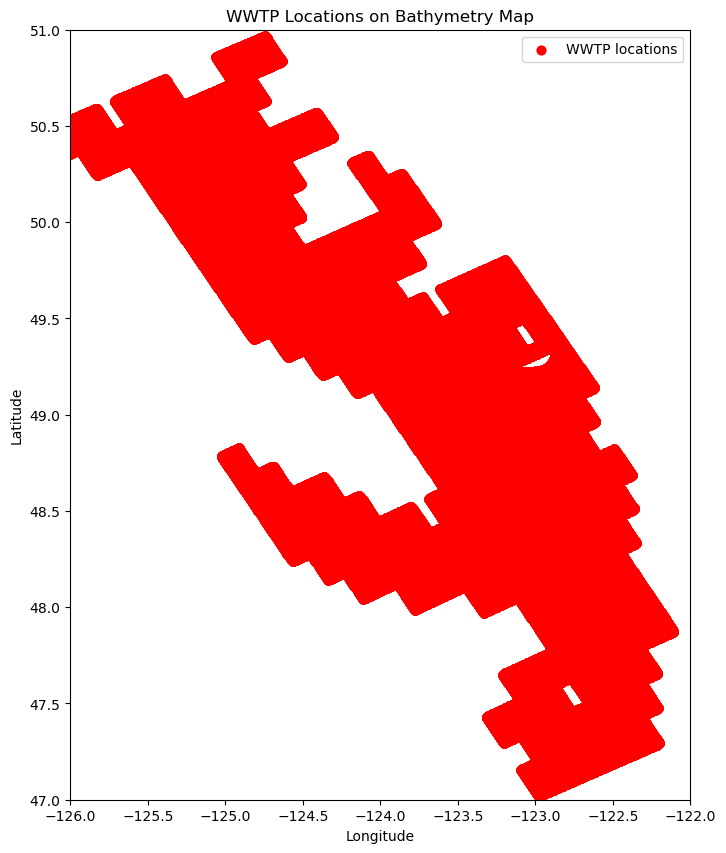

In [6]:
bathy_data = bathy["Bathymetry"]
lon_grid = bathy["nav_lon"]
lat_grid = bathy["nav_lat"]

fig, ax = plt.subplots(figsize=(8, 10))

mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=45)

ax.scatter(wwtp_locs["nav_lon"],wwtp_locs["nav_lat"],color="red",s=40,label="WWTP locations")
ax.set_xlabel("Longitude")
ax.set_xlim(-126,-122)
ax.set_ylabel("Latitude")
ax.set_ylim(47,51)
ax.set_title("WWTP Locations on Bathymetry Map")
ax.legend()
plt.show()

In [7]:
flux_max = file_usa["flux"].max(dim="time_counter") # keeps the maximum flux at each grid cell

print(flux_max.dims)
print(flux_max.shape)

('y', 'x')
(898, 398)


In [8]:
flux_nonzero = flux_max > 0
all_y, all_x = np.where(flux_nonzero.values)
print(f"Found {len(all_y)} sources")

Found 94 sources


In [9]:
lon = file_usa["nav_lon"].values
lat = file_usa["nav_lat"].values

print(lon.shape)
print(lat.shape)

(12, 898, 398)
(12, 898, 398)


In [10]:
# Get longitude and latitude grid because we only need one copy of the grid
lon = file_usa["nav_lon"].isel(time_counter=0).values
lat = file_usa["nav_lat"].isel(time_counter=0).values
print(lon.shape)
print(lat.shape)

(898, 398)
(898, 398)


In [11]:
wwtp_locs = pd.DataFrame({"y": all_y,"x": all_x,"lon": lon[all_y, all_x],"lat": lat[all_y, all_x],"max_flux": flux_max.values[all_y, all_x]})

wwtp_locs.head()

,y,x,lon,lat,max_flux
0,1,149,-122.640366,47.143044,0.000771
1,4,101,-122.905167,47.064884,0.002665
2,7,163,-122.585480,47.193027,0.003930
3,10,106,-122.897858,47.097782,0.000003
4,11,194,-122.433891,47.266994,0.004629


/home/dtaneja/analysis-dishika/.pixi/envs/default/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


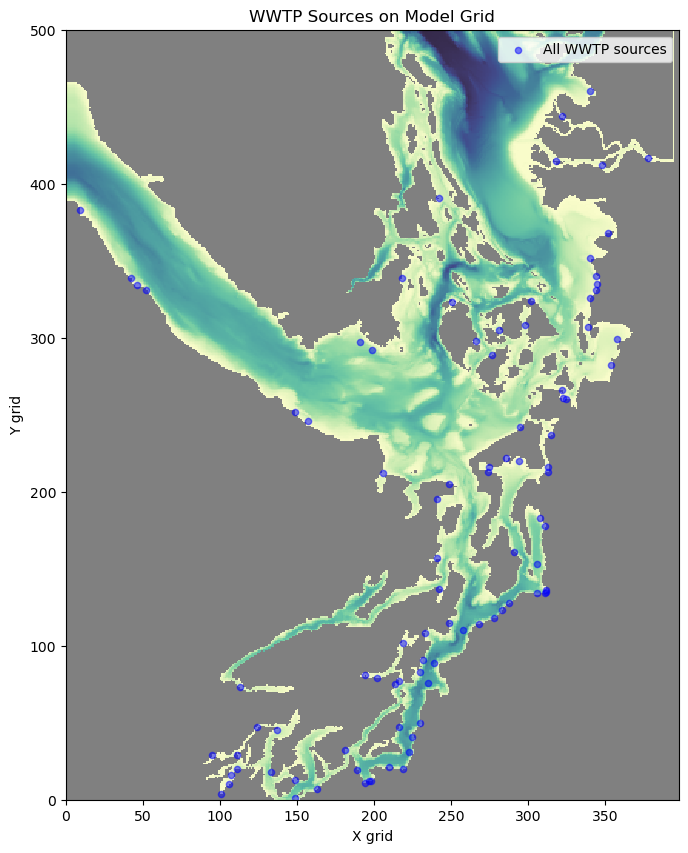

In [12]:
mycmap = cm.deep.copy()
mycmap.set_bad("grey")

fig, ax_map = plt.subplots(figsize=(8, 10))

bathy_data = bathy.variables["Bathymetry"][:]

ax_map.pcolormesh(bathy_data,cmap=mycmap,vmin=0,vmax=450)
ax_map.scatter(wwtp_locs["x"],wwtp_locs["y"],color="blue",alpha=0.5,s=20,label="All WWTP sources")
ax_map.set_title("WWTP Sources on Model Grid")
ax_map.set_xlabel("X grid")
ax_map.set_ylabel("Y grid")
ax_map.set_ylim(0, 500)
ax_map.legend()
ax_map.set_aspect("equal")

plt.show()

/tmp/ipykernel_477208/2708796783.py:7: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450)


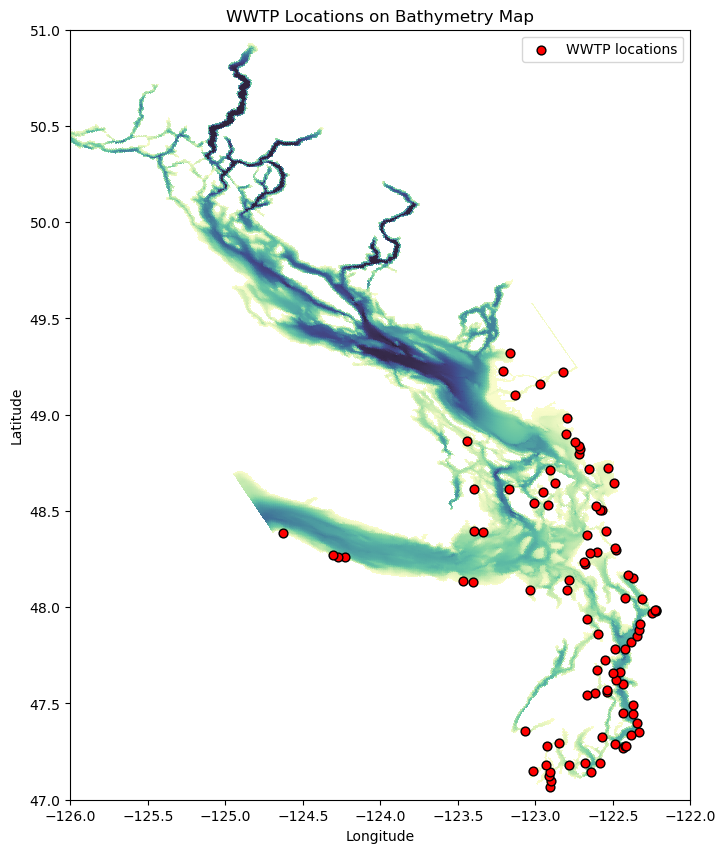

In [13]:
bathy_data = bathy["Bathymetry"]
lon_grid = bathy["nav_lon"]
lat_grid = bathy["nav_lat"]

fig, ax = plt.subplots(figsize=(8, 10))

mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450)

ax.scatter(wwtp_locs["lon"],wwtp_locs["lat"],color="red",edgecolors="black",s=40,label="WWTP locations")
ax.set_xlabel("Longitude")
ax.set_xlim(-126,-122)
ax.set_ylabel("Latitude")
ax.set_ylim(47,51)
ax.set_title("WWTP Locations on Bathymetry Map")
ax.legend()
plt.show()

In [14]:
iona_flux_max = file_iona["flux"].max(dim="time_counter").fillna(0)
iona_y, iona_x = np.where(iona_flux_max.values > 0)

print(f"Found {len(iona_y)} Iona source grid cell(s)")

iona_lon_grid = file_iona["nav_lon"].values
iona_lat_grid = file_iona["nav_lat"].values

iona_lon = iona_lon_grid[iona_y, iona_x]
iona_lat = iona_lat_grid[iona_y, iona_x]

print("Iona longitude:", iona_lon)
print("Iona latitude:", iona_lat)

Found 4 Iona source grid cell(s)
Iona longitude: [-123.30531  -123.30012  -123.30867  -123.303474]
Iona latitude: [49.198967 49.20085  49.202885 49.20477 ]


/tmp/ipykernel_477208/3412260971.py:3: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")
/home/dtaneja/analysis-dishika/.pixi/envs/default/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


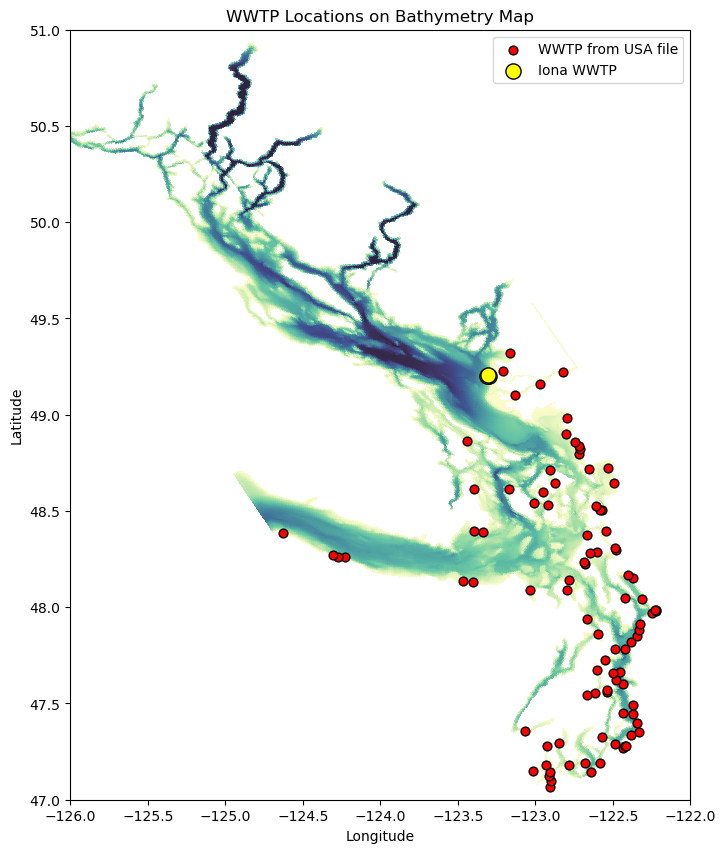

In [15]:
fig, ax = plt.subplots(figsize=(8, 10))

mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")

ax.scatter(wwtp_locs["lon"],wwtp_locs["lat"],color="red",edgecolors="black",s=40,label="WWTP from USA file")
ax.scatter(iona_lon,iona_lat,color="yellow",edgecolor="black",s=120,label="Iona WWTP")

ax.set_xlabel("Longitude")
ax.set_xlim(-126, -122)
ax.set_ylabel("Latitude")
ax.set_ylim(47, 51)
ax.set_title("WWTP Locations on Bathymetry Map")
ax.legend()
plt.show()

In [16]:
file_canada = pd.read_csv("/home/dtaneja/analysis-dishika/notebooks/RichvsMineWWTP.csv")
file_canada.head()

,Outfall Name from Valenti-Muelas et al. (2026),Outfall Name from Rich,Population,latitude,longitude,Depth,Flow,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19
0,NaN,Capital Regional District - Clover Point,NaN,48.402500,-123.348889,67,44915,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,BC Ferries,NaN,49.783333,-124.616670,3,"0,31",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,Van Anda,NaN,49.758333,-124.550000,35,"17,2",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,District of Campbell River,35519.0,50.048611,-125.258333,35,20000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,Powell River Regional District - Lund,NaN,49.981111,-124.761111,50,70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
file_canada = file_canada.rename(columns={
    "longitude": "lon",
    "latitude": "lat"
})

file_canada = file_canada.dropna(subset=["lon", "lat"])

/tmp/ipykernel_477208/1386068336.py:3: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")
/home/dtaneja/analysis-dishika/.pixi/envs/default/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


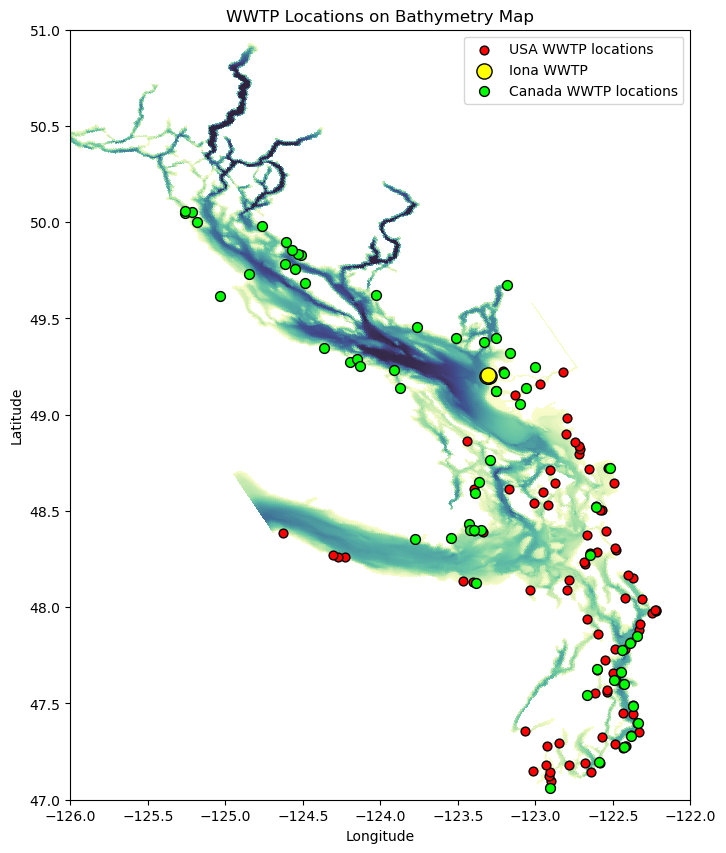

In [18]:
fig, ax = plt.subplots(figsize=(8, 10))

mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")

ax.scatter(wwtp_locs["lon"],wwtp_locs["lat"],color="red",edgecolors="black",s=40,label="USA WWTP locations")
ax.scatter(iona_lon,iona_lat,color="yellow",edgecolor="black",s=120,label="Iona WWTP")
ax.scatter(file_canada["lon"],file_canada["lat"],color="lime",edgecolor="black",s=50,label="Canada WWTP locations")
ax.set_xlabel("Longitude")
ax.set_xlim(-126, -122)
ax.set_ylabel("Latitude")
ax.set_ylim(47, 51)
ax.set_title("WWTP Locations on Bathymetry Map")
ax.legend()
plt.show()

In [19]:
# Function to calculate distance between two points given their longitude and latitude using the Haversine formula
def haversine_km(lon1, lat1, lon2, lat2):
    R = 6371  # Earth radius in km
    lon1 = np.radians(lon1)
    lat1 = np.radians(lat1)
    lon2 = np.radians(lon2)
    lat2 = np.radians(lat2)
    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = (np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2)
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

In [20]:
threshold_km = 2
min_distances = []

for _, canada_row in file_canada.iterrows():
    distances = haversine_km(canada_row["lon"],canada_row["lat"],wwtp_locs["lon"].values,wwtp_locs["lat"].values)
    min_distances.append(distances.min())

file_canada["nearest_usa_distance_km"] = min_distances

In [21]:
file_canada_filtered = file_canada[file_canada["nearest_usa_distance_km"] > threshold_km].copy()
print("Original Canada WWTP count:", len(file_canada))
print("Filtered Canada WWTP count:", len(file_canada_filtered))
print("Removed Canada WWTP count:", len(file_canada) - len(file_canada_filtered))

Original Canada WWTP count: 60
Filtered Canada WWTP count: 38
Removed Canada WWTP count: 22


/tmp/ipykernel_477208/799666377.py:3: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")
/home/dtaneja/analysis-dishika/.pixi/envs/default/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


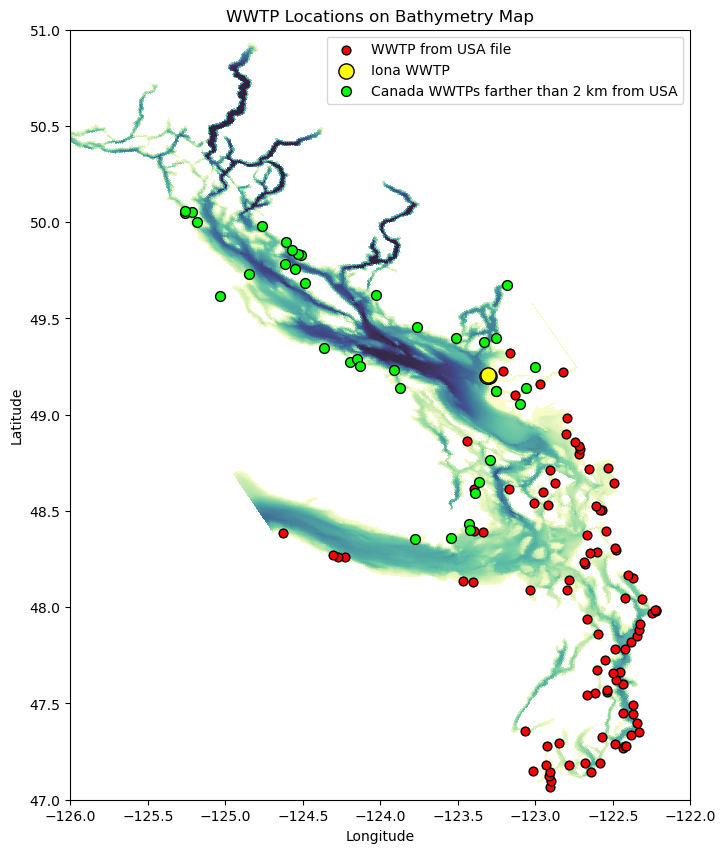

In [22]:
fig, ax = plt.subplots(figsize=(8, 10))

mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")

ax.scatter(wwtp_locs["lon"],wwtp_locs["lat"],color="red",edgecolors="black",s=40,label="WWTP from USA file")
ax.scatter(iona_lon,iona_lat,color="yellow",edgecolor="black",s=120,label="Iona WWTP")
ax.scatter(file_canada_filtered["lon"],file_canada_filtered["lat"],color="lime",edgecolors="black",s=50,label=f"Canada WWTPs farther than {threshold_km} km from USA")

ax.set_xlabel("Longitude")
ax.set_xlim(-126, -122)
ax.set_ylabel("Latitude")
ax.set_ylim(47, 51)
ax.set_title("WWTP Locations on Bathymetry Map")
ax.legend()

plt.show()

In [23]:
removed_canada = file_canada[file_canada["nearest_usa_distance_km"] <= threshold_km].copy()
removed_canada

,Outfall Name from Valenti-Muelas et al. (2026),Outfall Name from Rich,Population,lat,lon,Depth,Flow,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,nearest_usa_distance_km
0,NaN,Capital Regional District - Clover Point,NaN,48.402500,-123.348889,67,44915,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.510335
28,Iona,Greater Vancouver Sewerage and Drainage (Iona),NaN,49.217485,-123.201693,72-106,507000,NaN,howe,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.877626
34,Burrard_inlet,Greater Vancouver Regional District,NaN,49.321540,-123.165490,7.2,12900,NaN,howe,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000595
37,Bellingham,Bellingham,93910.0,48.723870,-122.519546,18,30520.75,NaN,fraser,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.800865
41,McLoughlin Point,McLoughlin Point WWTP,322245.0,48.400988,-123.397611,60,104730,NaN,jdf,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.572369
43,Port Angeles,Port Angeles,20200.0,48.128260,-123.379350,16,6565,NaN,jdf,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.680981
44,Anacortes,Anacortes,17880.0,48.523075,-122.609350,5811,5,NaN,skagit,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.157905
46,Bainbridge Island,Bainbridge Island,25060.0,47.622780,-122.489167,13,8144.5,NaN,puget,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.672458
47,South King,South King,714050.0,47.600585,-122.427888,190,232066,NaN,puget,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.355771
48,West King,West King,963450.0,47.661732,-122.449820,73,313121,NaN,puget,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.234890


In [24]:
threshold_km = 5
min_distances = []

for _, canada_row in file_canada.iterrows():
    distances = haversine_km(canada_row["lon"],canada_row["lat"],wwtp_locs["lon"].values,wwtp_locs["lat"].values)
    min_distances.append(distances.min())

file_canada["nearest_usa_distance_km"] = min_distances

file_canada_filtered = file_canada[file_canada["nearest_usa_distance_km"] > threshold_km].copy()
print("Original Canada WWTP count:", len(file_canada))
print("Filtered Canada WWTP count:", len(file_canada_filtered))
print("Removed Canada WWTP count:", len(file_canada) - len(file_canada_filtered))

Original Canada WWTP count: 60
Filtered Canada WWTP count: 34
Removed Canada WWTP count: 26


/tmp/ipykernel_477208/799666377.py:3: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")
/home/dtaneja/analysis-dishika/.pixi/envs/default/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


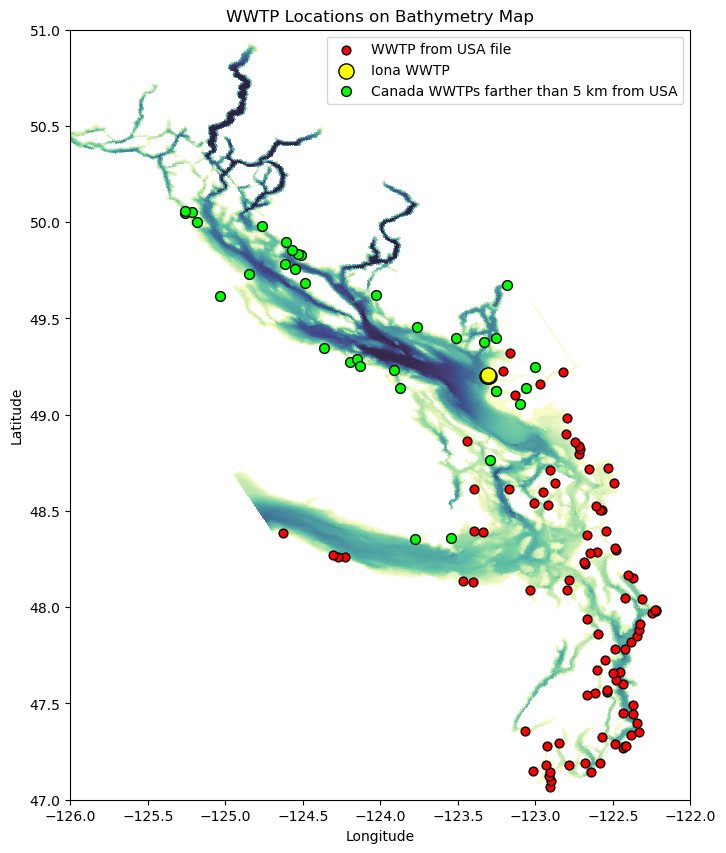

In [25]:
fig, ax = plt.subplots(figsize=(8, 10))

mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")

ax.scatter(wwtp_locs["lon"],wwtp_locs["lat"],color="red",edgecolors="black",s=40,label="WWTP from USA file")
ax.scatter(iona_lon,iona_lat,color="yellow",edgecolor="black",s=120,label="Iona WWTP")
ax.scatter(file_canada_filtered["lon"],file_canada_filtered["lat"],color="lime",edgecolors="black",s=50,label=f"Canada WWTPs farther than {threshold_km} km from USA")

ax.set_xlabel("Longitude")
ax.set_xlim(-126, -122)
ax.set_ylabel("Latitude")
ax.set_ylim(47, 51)
ax.set_title("WWTP Locations on Bathymetry Map")
ax.legend()

plt.show()

Original Canada WWTP count: 60
Filtered Canada WWTP count: 36
Removed Canada WWTP count: 24


/tmp/ipykernel_477208/2483870730.py:17: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")
/home/dtaneja/analysis-dishika/.pixi/envs/default/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


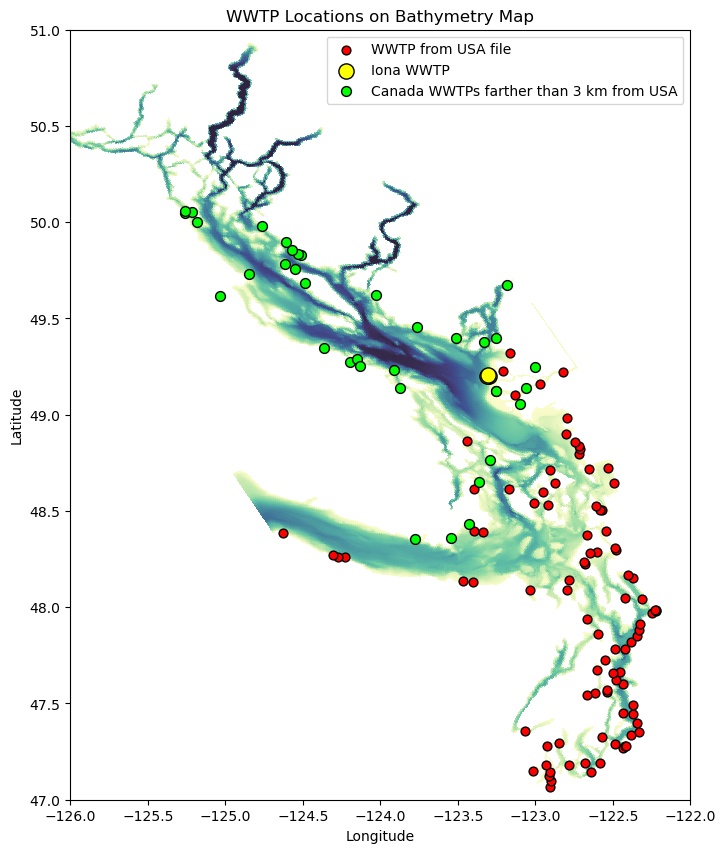

In [26]:
threshold_km = 3
min_distances = []

for _, canada_row in file_canada.iterrows():
    distances = haversine_km(canada_row["lon"],canada_row["lat"],wwtp_locs["lon"].values,wwtp_locs["lat"].values)
    min_distances.append(distances.min())

file_canada["nearest_usa_distance_km"] = min_distances

file_canada_filtered = file_canada[file_canada["nearest_usa_distance_km"] > threshold_km].copy()
print("Original Canada WWTP count:", len(file_canada))
print("Filtered Canada WWTP count:", len(file_canada_filtered))
print("Removed Canada WWTP count:", len(file_canada) - len(file_canada_filtered))

fig, ax = plt.subplots(figsize=(8, 10))

mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")

ax.scatter(wwtp_locs["lon"],wwtp_locs["lat"],color="red",edgecolors="black",s=40,label="WWTP from USA file")
ax.scatter(iona_lon,iona_lat,color="yellow",edgecolor="black",s=120,label="Iona WWTP")
ax.scatter(file_canada_filtered["lon"],file_canada_filtered["lat"],color="lime",edgecolors="black",s=50,label=f"Canada WWTPs farther than {threshold_km} km from USA")

ax.set_xlabel("Longitude")
ax.set_xlim(-126, -122)
ax.set_ylabel("Latitude")
ax.set_ylim(47, 51)
ax.set_title("WWTP Locations on Bathymetry Map")
ax.legend()

plt.show()

Original Canada WWTP count: 60
Filtered Canada WWTP count: 36
Removed Canada WWTP count: 24


/tmp/ipykernel_477208/1290980534.py:17: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")
/home/dtaneja/analysis-dishika/.pixi/envs/default/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


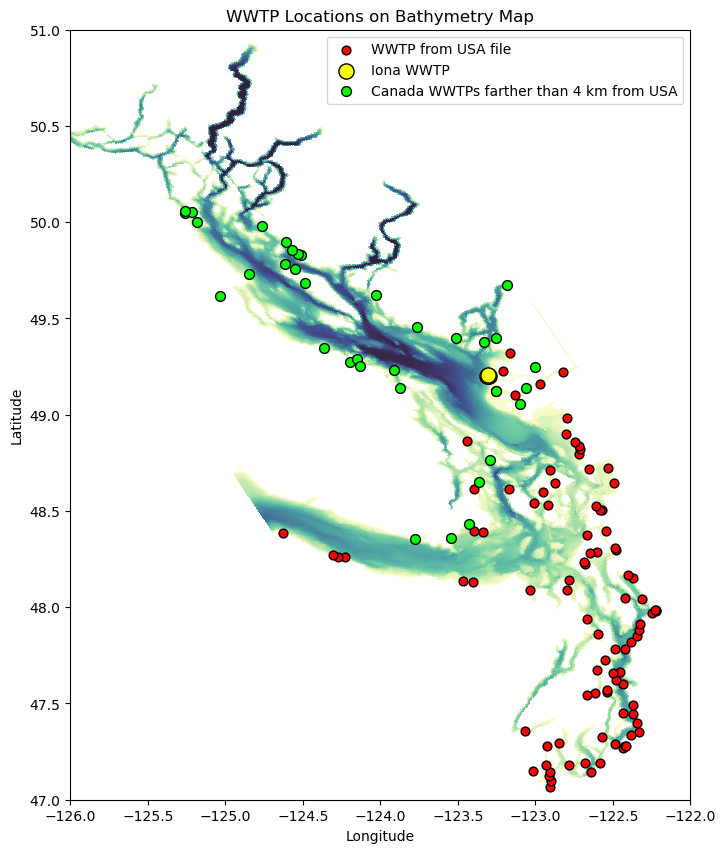

In [27]:
threshold_km = 4
min_distances = []

for _, canada_row in file_canada.iterrows():
    distances = haversine_km(canada_row["lon"],canada_row["lat"],wwtp_locs["lon"].values,wwtp_locs["lat"].values)
    min_distances.append(distances.min())

file_canada["nearest_usa_distance_km"] = min_distances

file_canada_filtered = file_canada[file_canada["nearest_usa_distance_km"] > threshold_km].copy()
print("Original Canada WWTP count:", len(file_canada))
print("Filtered Canada WWTP count:", len(file_canada_filtered))
print("Removed Canada WWTP count:", len(file_canada) - len(file_canada_filtered))

fig, ax = plt.subplots(figsize=(8, 10))

mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")

ax.scatter(wwtp_locs["lon"],wwtp_locs["lat"],color="red",edgecolors="black",s=40,label="WWTP from USA file")
ax.scatter(iona_lon,iona_lat,color="yellow",edgecolor="black",s=120,label="Iona WWTP")
ax.scatter(file_canada_filtered["lon"],file_canada_filtered["lat"],color="lime",edgecolors="black",s=50,label=f"Canada WWTPs farther than {threshold_km} km from USA")

ax.set_xlabel("Longitude")
ax.set_xlim(-126, -122)
ax.set_ylabel("Latitude")
ax.set_ylim(47, 51)
ax.set_title("WWTP Locations on Bathymetry Map")
ax.legend()

plt.show()

Original Canada WWTP count: 60
Filtered Canada WWTP count: 32
Removed Canada WWTP count: 28


/tmp/ipykernel_477208/3895793859.py:17: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")
/home/dtaneja/analysis-dishika/.pixi/envs/default/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


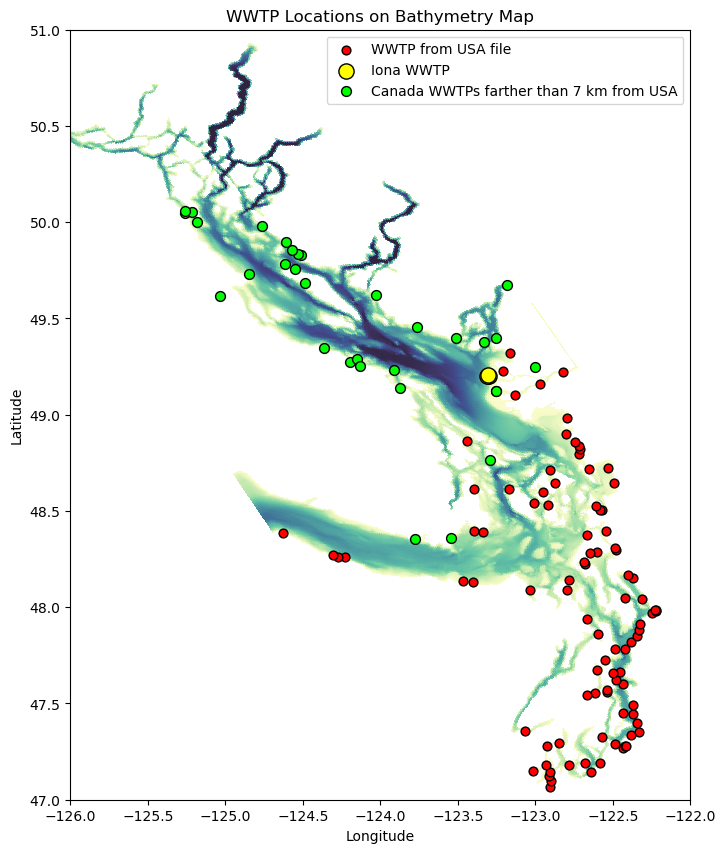

In [28]:
threshold_km = 7
min_distances = []

for _, canada_row in file_canada.iterrows():
    distances = haversine_km(canada_row["lon"],canada_row["lat"],wwtp_locs["lon"].values,wwtp_locs["lat"].values)
    min_distances.append(distances.min())

file_canada["nearest_usa_distance_km"] = min_distances

file_canada_filtered = file_canada[file_canada["nearest_usa_distance_km"] > threshold_km].copy()
print("Original Canada WWTP count:", len(file_canada))
print("Filtered Canada WWTP count:", len(file_canada_filtered))
print("Removed Canada WWTP count:", len(file_canada) - len(file_canada_filtered))

fig, ax = plt.subplots(figsize=(8, 10))

mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")

ax.scatter(wwtp_locs["lon"],wwtp_locs["lat"],color="red",edgecolors="black",s=40,label="WWTP from USA file")
ax.scatter(iona_lon,iona_lat,color="yellow",edgecolor="black",s=120,label="Iona WWTP")
ax.scatter(file_canada_filtered["lon"],file_canada_filtered["lat"],color="lime",edgecolors="black",s=50,label=f"Canada WWTPs farther than {threshold_km} km from USA")

ax.set_xlabel("Longitude")
ax.set_xlim(-126, -122)
ax.set_ylabel("Latitude")
ax.set_ylim(47, 51)
ax.set_title("WWTP Locations on Bathymetry Map")
ax.legend()

plt.show()

Original Canada WWTP count: 60
Filtered Canada WWTP count: 34
Removed Canada WWTP count: 26


/tmp/ipykernel_477208/3476536819.py:17: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")
/home/dtaneja/analysis-dishika/.pixi/envs/default/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


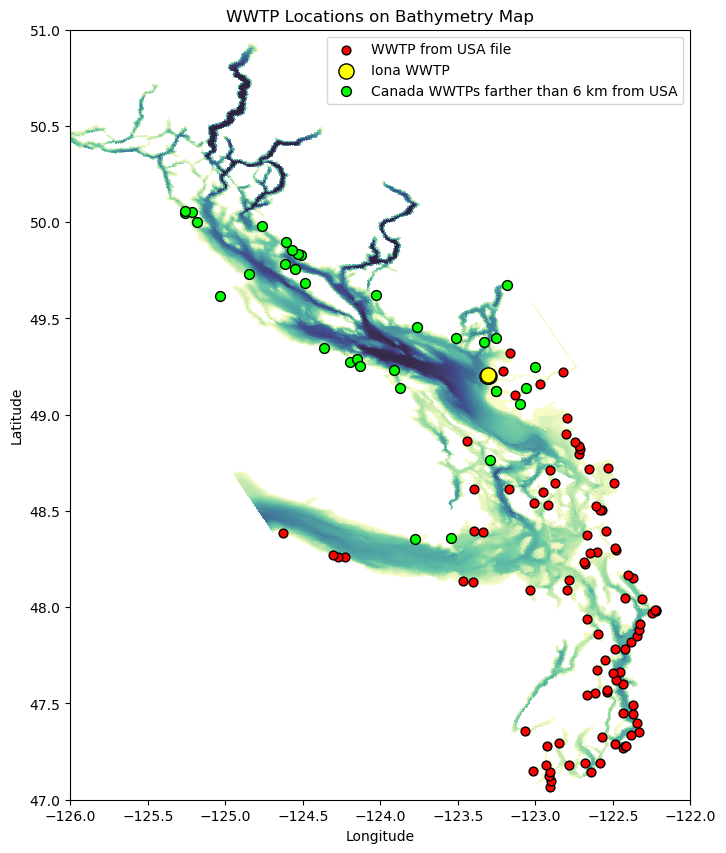

In [29]:
threshold_km = 6
min_distances = []

for _, canada_row in file_canada.iterrows():
    distances = haversine_km(canada_row["lon"],canada_row["lat"],wwtp_locs["lon"].values,wwtp_locs["lat"].values)
    min_distances.append(distances.min())

file_canada["nearest_usa_distance_km"] = min_distances

file_canada_filtered = file_canada[file_canada["nearest_usa_distance_km"] > threshold_km].copy()
print("Original Canada WWTP count:", len(file_canada))
print("Filtered Canada WWTP count:", len(file_canada_filtered))
print("Removed Canada WWTP count:", len(file_canada) - len(file_canada_filtered))

fig, ax = plt.subplots(figsize=(8, 10))

mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")

ax.scatter(wwtp_locs["lon"],wwtp_locs["lat"],color="red",edgecolors="black",s=40,label="WWTP from USA file")
ax.scatter(iona_lon,iona_lat,color="yellow",edgecolor="black",s=120,label="Iona WWTP")
ax.scatter(file_canada_filtered["lon"],file_canada_filtered["lat"],color="lime",edgecolors="black",s=50,label=f"Canada WWTPs farther than {threshold_km} km from USA")

ax.set_xlabel("Longitude")
ax.set_xlim(-126, -122)
ax.set_ylabel("Latitude")
ax.set_ylim(47, 51)
ax.set_title("WWTP Locations on Bathymetry Map")
ax.legend()

plt.show()